# Prerequisites · M3 — Probability & Statistics for Deep Learning

> **Goal:** the probability that underpins **loss functions, generative models, and RL** — random variables, the key distributions (Bernoulli, categorical, Gaussian), expectation/variance, **maximum likelihood** (which *is* where cross-entropy comes from), Bayes, and **Monte Carlo sampling** — from scratch, tied to the notebooks.

**Why.** Deep learning is probabilistic to its core: a classifier outputs a *distribution* over classes; cross-entropy loss is *negative log-likelihood*; VAEs and diffusion model *distributions* and sample from them; RL maximizes *expected* reward. If you understand distributions, expectation, and maximum likelihood, most loss functions stop being arbitrary formulas and become "maximize the probability of the data."


In [1]:
import numpy as np
import matplotlib.pyplot as plt
np.random.seed(0)   # so the sampled figures reproduce
%matplotlib inline
rng = np.random.default_rng(0)


## 1. Random variables & the three distributions you'll actually use

A **random variable** takes values with certain probabilities, described by a distribution (PMF for discrete, PDF for continuous). Three cover almost all of deep learning:
- **Bernoulli** (a coin): outcome 0/1 with probability $p$. → binary classification, dropout masks.
- **Categorical** (a die): one of $K$ outcomes with probabilities $p_1,\dots,p_K$ summing to 1. → **softmax outputs**, next-token prediction.
- **Gaussian / Normal** $\mathcal{N}(\mu,\sigma^2)$: the bell curve, PDF $\frac{1}{\sqrt{2\pi\sigma^2}}e^{-(x-\mu)^2/2\sigma^2}$. → weight init, VAE latents, diffusion noise, regression.


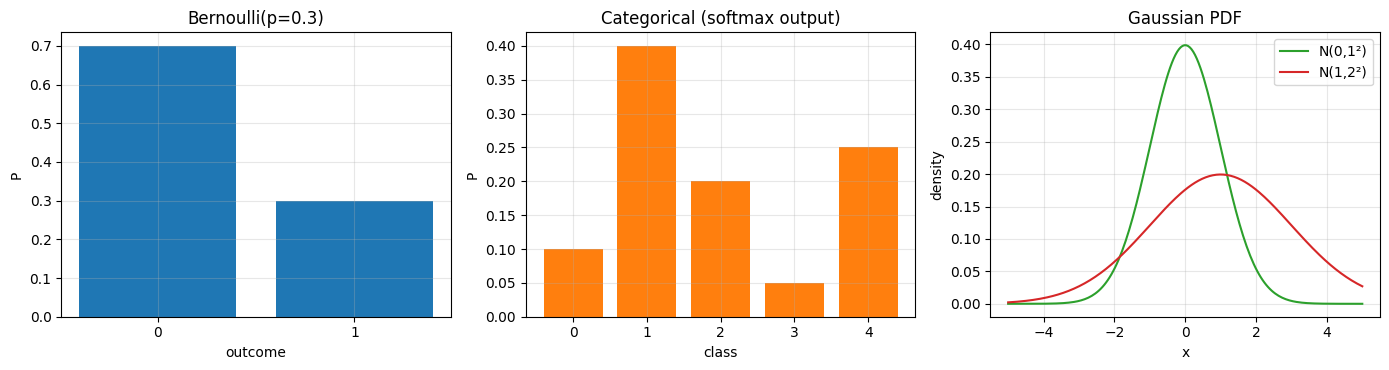

In [2]:
fig, ax = plt.subplots(1,3,figsize=(14,3.8))
# Bernoulli(p=0.3)
ax[0].bar([0,1],[0.7,0.3],color="tab:blue"); ax[0].set_title("Bernoulli(p=0.3)"); ax[0].set_xticks([0,1]); ax[0].set_xlabel("outcome"); ax[0].set_ylabel("P")
# Categorical
probs = np.array([0.1,0.4,0.2,0.05,0.25]); ax[1].bar(range(5),probs,color="tab:orange"); ax[1].set_title("Categorical (softmax output)"); ax[1].set_xlabel("class"); ax[1].set_ylabel("P")
# Gaussian
xs = np.linspace(-5,5,200)
def gauss_pdf(x,mu,sig): return np.exp(-(x-mu)**2/(2*sig**2))/np.sqrt(2*np.pi*sig**2)
for mu,sig,c in [(0,1,"tab:green"),(1,2,"tab:red")]:
    ax[2].plot(xs, gauss_pdf(xs,mu,sig), color=c, label=f"N({mu},{sig}²)")
ax[2].set_title("Gaussian PDF"); ax[2].set_xlabel("x"); ax[2].set_ylabel("density"); ax[2].legend()
for a in ax: a.grid(alpha=0.3)
plt.tight_layout(); plt.show()


**↳ Used in:** softmax = a categorical distribution over tokens/classes (NB02, NB11); Gaussian latents in VAEs (NB23); Gaussian noise in diffusion (NB25); Bernoulli dropout masks (NB06).


## 2. Expectation & variance — and estimating them by sampling

- **Expectation** $\mathbb{E}[X] = \sum_x x\,p(x)$ (or $\int x\,p(x)\,dx$) — the long-run average / "center of mass."
- **Variance** $\text{Var}[X] = \mathbb{E}[(X-\mu)^2]$ — the spread.

In practice we rarely have the true distribution — we **estimate** expectations from *samples* (**Monte Carlo**): $\mathbb{E}[f(X)] \approx \frac{1}{N}\sum_i f(x_i)$. This is one of the most important ideas in ML — it's how we estimate a loss from a minibatch, an RL return from rollouts, and a VAE's ELBO. The estimate converges as $1/\sqrt{N}$.


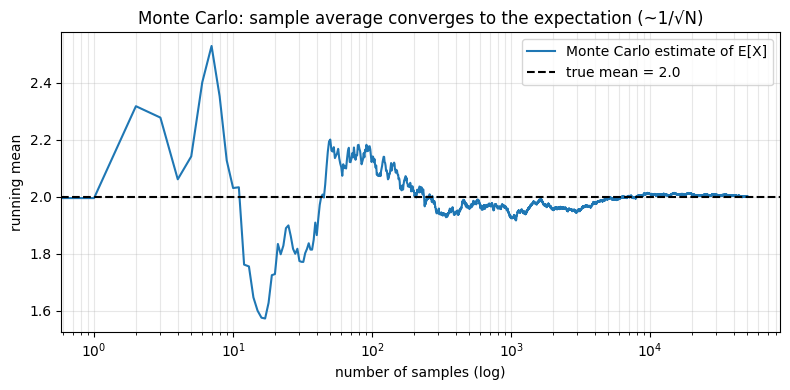

estimate after 50k samples: 2.0013 (true 2.0); sample variance 2.256 (true 2.25)


In [3]:
# estimate E[X] for a Gaussian by sampling, and watch it converge
true_mean = 2.0
samples = rng.normal(true_mean, 1.5, 50000)
running = np.cumsum(samples)/np.arange(1, len(samples)+1)
fig, ax = plt.subplots(figsize=(8,4))
ax.plot(running, color="tab:blue", label="Monte Carlo estimate of E[X]")
ax.axhline(true_mean, ls="--", color="k", label="true mean = 2.0")
ax.set_xscale("log"); ax.set_title("Monte Carlo: sample average converges to the expectation (~1/√N)")
ax.set_xlabel("number of samples (log)"); ax.set_ylabel("running mean"); ax.legend(); ax.grid(alpha=0.3, which="both")
plt.tight_layout(); plt.show()
print(f"estimate after 50k samples: {running[-1]:.4f} (true 2.0); sample variance {samples.var():.3f} (true {1.5**2})")
assert abs(running[-1] - true_mean) < 0.05, \
    f"Monte Carlo estimate {running[-1]:.4f} has not converged to the true mean {true_mean}"
assert abs(samples.var() - 1.5**2) < 0.1, \
    f"sample variance {samples.var():.3f} does not match the true {1.5**2}"


**↳ Used in:** minibatch loss = a Monte Carlo estimate of the full-dataset loss (NB06); RL value estimates from sampled returns (NB33–37); VAE's ELBO expectation (NB23).


## 3. Why the Gaussian is everywhere — the Central Limit Theorem

The **Central Limit Theorem** says: the sum (or average) of many independent random variables tends toward a **Gaussian**, *regardless of their original distribution*. This is why the Gaussian is the default noise/prior model — sums of many small independent effects (like the many terms in a weight's gradient, or pixel noise) are approximately Gaussian. Let's watch it happen: average more and more *uniform* random variables and the result becomes a bell curve.


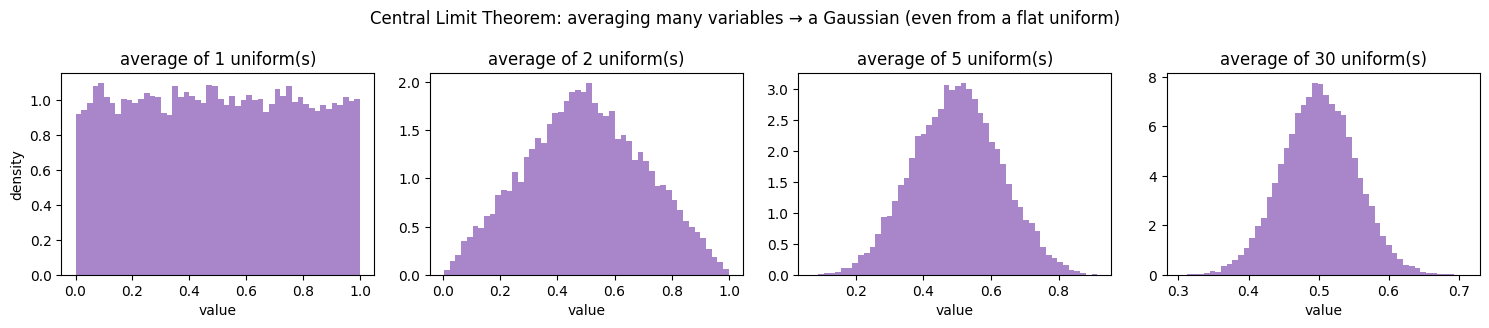

In [4]:
fig, ax = plt.subplots(1,4,figsize=(15,3.3))
for a, k in zip(ax, [1, 2, 5, 30]):
    means = rng.uniform(0,1,(20000,k)).mean(axis=1)     # average of k uniforms
    a.hist(means, bins=50, density=True, color="tab:purple", alpha=0.8)
    a.set_title(f"average of {k} uniform(s)"); a.set_xlabel("value"); a.set_ylabel("density" if k==1 else "")
fig.suptitle("Central Limit Theorem: averaging many variables → a Gaussian (even from a flat uniform)")
plt.tight_layout(); plt.show()


**↳ Used in:** the assumption that gradients/activations are approximately Gaussian, which underlies weight init (NB05) and mixed-precision numerics (NB15).


## 4. Maximum Likelihood — where cross-entropy and MSE come from

**Maximum Likelihood Estimation (MLE)** is the master principle behind almost every loss function: *choose the parameters that make the observed data most probable.* We maximize the likelihood $\prod_i p(x_i;\theta)$, or equivalently minimize the **negative log-likelihood** $-\sum_i \log p(x_i;\theta)$ (logs turn products into sums and are numerically nicer).

Two huge consequences:
- **Classification:** modeling labels as a categorical distribution and doing MLE gives *exactly* **cross-entropy loss**. Cross-entropy isn't arbitrary — it's "maximize the probability the model assigns to the true labels."
- **Regression:** modeling targets as Gaussian-distributed around the prediction and doing MLE gives *exactly* **mean-squared error**.

Let's verify MLE for a Gaussian: the maximum-likelihood $\mu,\sigma^2$ are just the **sample mean and variance**.


MLE μ = sample mean     = 3.0167  (true 3.0)
MLE σ²= sample variance = 4.1599  (true 4.0)


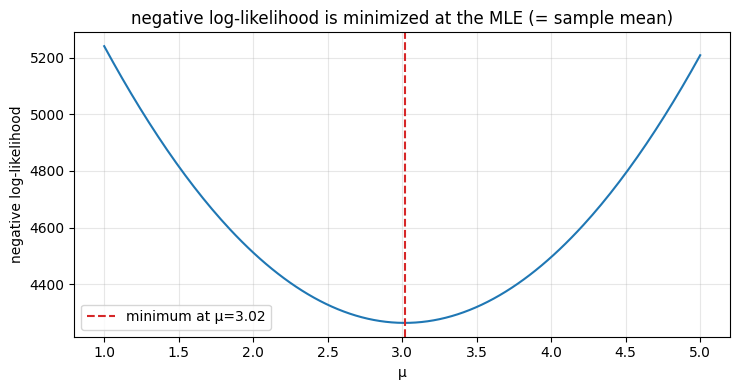


Cross-entropy loss = MLE for a categorical model. MSE loss = MLE for a Gaussian model.


In [5]:
data = rng.normal(3.0, 2.0, 2000)                      # true mu=3, sigma=2
# MLE estimates (derived by setting d(neg-log-likelihood)/dparam = 0):
mu_mle = data.mean()
var_mle = data.var()                                    # = mean((x-mu)^2)
print(f"MLE μ = sample mean     = {mu_mle:.4f}  (true 3.0)")
print(f"MLE σ²= sample variance = {var_mle:.4f}  (true 4.0)")

# scan the log-likelihood over mu to SHOW the maximum is at the sample mean
def neg_log_lik(mu, sig2, x): return 0.5*np.sum((x-mu)**2/sig2 + np.log(2*np.pi*sig2))
mus = np.linspace(1,5,200); nll = [neg_log_lik(m, var_mle, data) for m in mus]
fig, ax = plt.subplots(figsize=(7.5,4))
ax.plot(mus, nll, color="tab:blue"); ax.axvline(mu_mle, ls="--", color="tab:red", label=f"minimum at μ={mu_mle:.2f}")
ax.set_title("negative log-likelihood is minimized at the MLE (= sample mean)")
ax.set_xlabel("μ"); ax.set_ylabel("negative log-likelihood"); ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()
print("\nCross-entropy loss = MLE for a categorical model. MSE loss = MLE for a Gaussian model.")
assert abs(mu_mle - data.mean()) < 1e-9, \
    f"the Gaussian MLE for the mean should BE the sample mean: {mu_mle} vs {data.mean()}"
assert abs(var_mle - data.var()) < 1e-9, \
    f"the Gaussian MLE for the variance should BE the sample variance: {var_mle} vs {data.var()}"


**↳ Used in:** cross-entropy in *every* classifier and language model (NB02, NB11); MSE in regression and diffusion's noise-prediction loss (NB25); the reward model's Bradley-Terry loss is MLE over preferences (NB21); flows maximize *exact* likelihood (NB26).


## 5. Bayes' rule — updating beliefs with evidence

**Bayes' rule** inverts conditional probabilities:
$$p(\theta\mid \text{data}) = \frac{p(\text{data}\mid\theta)\,p(\theta)}{p(\text{data})} \;\propto\; \underbrace{p(\text{data}\mid\theta)}_{\text{likelihood}}\;\underbrace{p(\theta)}_{\text{prior}}.$$
It tells you how to update a **prior** belief into a **posterior** after seeing evidence. It's the foundation of Bayesian ML, and it's the lens behind the VAE (which does approximate Bayesian inference over latents) and regularization (weight decay = a Gaussian prior on weights). Quick demo: infer the bias of a coin as we see flips.


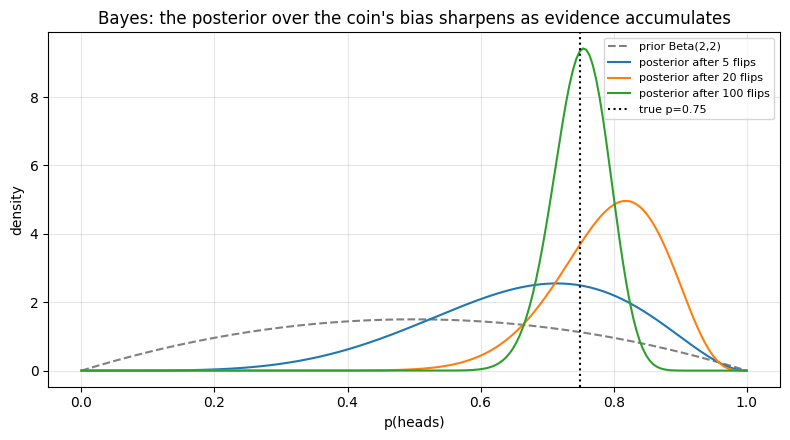

In [6]:
# Beta-Bernoulli: prior Beta(2,2), observe coin flips, update the posterior over p(heads)
def beta_pdf(x, a, b):
    from math import gamma
    return x**(a-1)*(1-x)**(b-1) * gamma(a+b)/(gamma(a)*gamma(b))
true_p = 0.75
xs = np.linspace(0,1,200)
fig, ax = plt.subplots(figsize=(8,4.5))
a, b = 2, 2                                             # prior
ax.plot(xs, [beta_pdf(x,a,b) for x in xs], "--", color="gray", label="prior Beta(2,2)")
for n in [5, 20, 100]:
    flips = rng.random(n) < true_p
    heads, tails = flips.sum(), n-flips.sum()
    ax.plot(xs, [beta_pdf(x, a+heads, b+tails) for x in xs], label=f"posterior after {n} flips")
ax.axvline(true_p, ls=":", color="k", label="true p=0.75")
ax.set_title("Bayes: the posterior over the coin's bias sharpens as evidence accumulates")
ax.set_xlabel("p(heads)"); ax.set_ylabel("density"); ax.legend(fontsize=8); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()


**What to notice.** With little data the posterior is broad (uncertain); as flips accumulate it concentrates around the true bias. That's the Bayesian view of learning: **data sharpens beliefs**.

**↳ Used in:** the VAE's approximate posterior $q(z\mid x)$ (NB23); weight decay as a Gaussian prior (NB04); the whole framing of "prior + likelihood → posterior" in probabilistic ML.

## What you learned
- **Distributions**: Bernoulli, categorical (softmax!), Gaussian — the three you'll actually use.
- **Expectation & variance**, estimated by **Monte Carlo sampling** (minibatches, RL returns, ELBO).
- **CLT**: why the Gaussian is everywhere (sums of many effects → Gaussian).
- **Maximum likelihood**: the origin of cross-entropy (categorical MLE) and MSE (Gaussian MLE).
- **Bayes' rule**: prior → posterior; the lens behind VAEs and regularization.

## Exercises
1. **CE = NLL.** Show that minimizing cross-entropy equals maximizing the log-likelihood of a categorical model. (You used this in NB02/NB11.)
2. **MSE = Gaussian MLE.** Derive MSE from assuming $y\sim\mathcal{N}(\hat y,\sigma^2)$ and doing MLE.
3. **Reparameterization.** Sample $\mathcal{N}(\mu,\sigma^2)$ as $\mu+\sigma\varepsilon$; why does this matter for gradients (NB23)?
4. **Importance sampling.** Estimate $\mathbb{E}_{p}[f]$ using samples from a different $q$; where does this appear in RL/PPO (NB37)?
5. **KL between Gaussians.** Derive the closed-form KL used in the VAE (NB23) — a preview of M4.
6. **Bias of variance MLE.** Show the MLE variance is biased ($\frac1N$ vs $\frac1{N-1}$); why does it barely matter at DL scale?

## 📚 References & further reading
- **Deep Learning** — Goodfellow, Bengio & Courville (2016), Chapter 3 ("Probability and Information Theory").
- **Pattern Recognition and Machine Learning** — Bishop (2006), Chapters 1–2. The Bayesian/ML foundations.
- **Probability Theory: The Logic of Science** — Jaynes. The deep Bayesian view.
- **Information Theory, Inference, and Learning Algorithms** — MacKay (2003, free online). Probability + information theory for ML.

---
**Next:** *Prerequisites · M4 — Information theory*: entropy, cross-entropy, and KL divergence — the "distance between distributions" that defines classification loss (NB11), the VAE/RLHF KL term (NB21, NB23), and distillation (NB30).
